**[Content]**
1. 데이터 분석(EDA)
2. 모델링 과정 및 평가
3. 프로젝트를 통해 얻은 인사이트
4. 향후 개선 방향

# 1. 데이터 분석(EDA)
- 1-1. 데이터 출처 설명 및 데이터 선정 이유
- 1-2. 기초 통계량 확인
- 1-3. 분석 목적/인사이트 설명
- 1-4. 변수 간 관계 분석 및 시각화

## 1.1 데이터 출처 설명 및 데이터 선정 이유
- **선택한 데이터**: uci-secom.csv  
- **출처**: https://www.kaggle.com/datasets/paresh2047/uci-semcom/code
- **데이터 설명**: 실제 반도체 웨이퍼 제작 공정에서 발생한 591개의 센서 측정값과 그에 따른 합격/불량(Pass/Fail) 결과로 이루어져 있음.
- **데이터 선정 이유**: 극심한 데이터 불균형(불량 비율이 약 6.3%), 대규모 결측치 처리, 고차원 및 다중공선성, 도메인 해석력(센서 이름이 익명임)과 같은 전반적으로 데이터 분석에 있어 해결해야 할 난제들을 대부분 갖추고 있음. Develop Session 동안 배운 기법들을 자유롭게 적용할 기회라고 생각하여 데이터를 선정함.


In [1]:
# 기초 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 'data'에 데이터 로드
data = pd.read_csv('uci-secom.csv')

# 데이터의 사이즈 확인
print(f"데이터 크기: {data.shape}\n")

# 데이터 요약 정보 확인
print("[데이터 요약 정보]")
data.info()
print("\n")

# 5개의 샘플 살펴보기
data.head(5)

데이터 크기: (1567, 592)

[데이터 요약 정보]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB




,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


[해석]
- 1567개의 행(샘플수), 592개의 칼럼으로 구성되어있음.
- 칼럼1: 샘플 생산 날짜(Time)
- 칼럼592: 샘플의 Pass/Fail 여부. 정상은 -1, 불량은 1
- 나머지 칼럼: float64 실수 데이터

## 1-2. 기초 통계량 확인

In [2]:
# 칼럼별 기초 통계량 확인
display(data.describe())

,0,1,2,3,4,5,6,7,8,9,...,581,582,583,584,585,586,587,588,589,Pass/Fail
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1567.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066,-0.867262
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919,0.498010
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000,-1.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600,-1.000000
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500,-1.000000
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700,-1.000000
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800,1.000000


[해석]

- 데이터의 총 개수: 1,567개
- count가 1567보다 작은 칼럼: **결측치**가 존재한다는 뜻. 결측치 분석 필요.
- std가 0: **상수**라는 뜻. 결과에 아무런 영향을 미치지 못함. 삭제 필요.
- min, max가 50%와 크게 차이나는 센서: **이상치** 존재한다는 뜻.

## 1-3. 분석 목적/인사이트 설명
- 590개에 달하는 센서 중 제품 품질에 영향을 미치는 **핵심 센서**를 찾음.

## 1-4. 변수 간 관계 분석 및 시각화
- (A) Target 분포 확인 (Pass/Fail ratio)
- (B) 결측치 상위 칼럼 확인
- (C) 상관계수 상위 칼럼 확인
- (D) 이상치 확인

### 1-4-(A). Target 분포 확인 (Pass/Fail ratio)

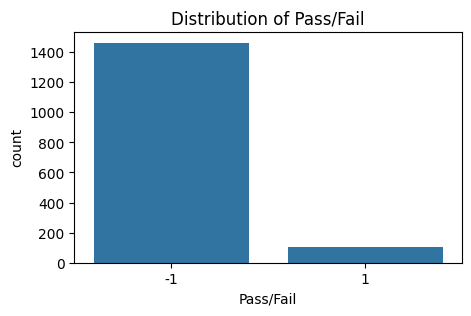

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64
정상(-1):  1463 개
불량(1):  104 개
불량률: 6.64%


In [3]:
# Pass/Fail 개수를 seaborn.countplot(막대그래프)로 확인
plt.figure(figsize = (5, 3))
sns.countplot(x='Pass/Fail', data=data)
plt.title('Distribution of Pass/Fail')
plt.show()

# 정확한 수치 확인
print(data['Pass/Fail'].value_counts())
print("정상(-1): ", data['Pass/Fail'].value_counts()[-1], "개") # 정상 개수
print("불량(1): ", data['Pass/Fail'].value_counts()[1], "개") # 불량 개수
print("불량률: {}%".format(round(data['Pass/Fail'].value_counts()[1] / len(data) * 100, 2))) # (불량 / 전체) 비율

[해석]
- 정상 샘플이 불량 샘플보다 압도적으로 많음.(불량률 6.64%)
- 추후 SMOTE 기법을 통해 불량률을 높이는 전처리가 필요해보임.
- 불균형 데이터이므로 모델 학습 시 유의해야 함.

### 1-4-(B). 결측치 상위 칼럼 확인

- 칼럼마다 결측치 비율(0~1)을 구하고, 가장 높은 값부터 상위 40개를 그래프로 나타냄.


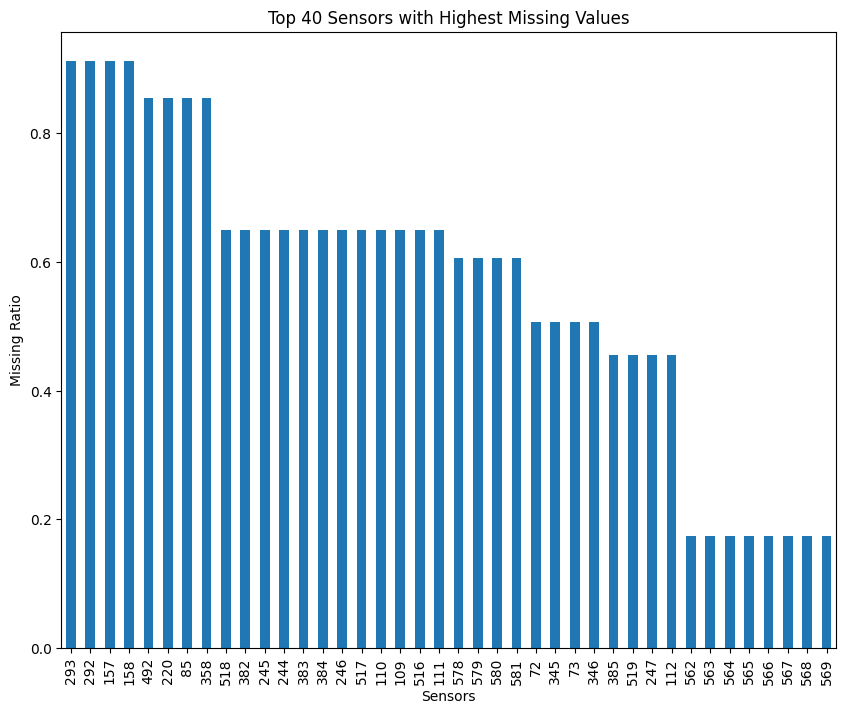

In [4]:
# 칼럼마다 결측치 개수의 평균(즉, 결측치 비율)을 내림차순 정렬
missing_probs = data.isnull().mean(axis=0).sort_values(ascending=False)

# 결측치 비율 상위 40개의 데이터를 막대그래프로 표시
plt.figure(figsize = (10, 8))
missing_probs[:40].plot(kind = 'bar')
plt.title('Top 40 Sensors with Highest Missing Values')
plt.xlabel('Sensors')
plt.ylabel('Missing Ratio')
plt.show()

[해석]
- 실제 공정에서는 결측치 비율이 0.5 이상인 센서는 불량 센서로 판단하는 경우가 많음. 따라서 해당 센서들은 추후 제거 필요.

### 1-4-(C). 상관계수 상위 센서 확인
- 타겟과 상관계수가 높은 상위 20개의 센서 확인

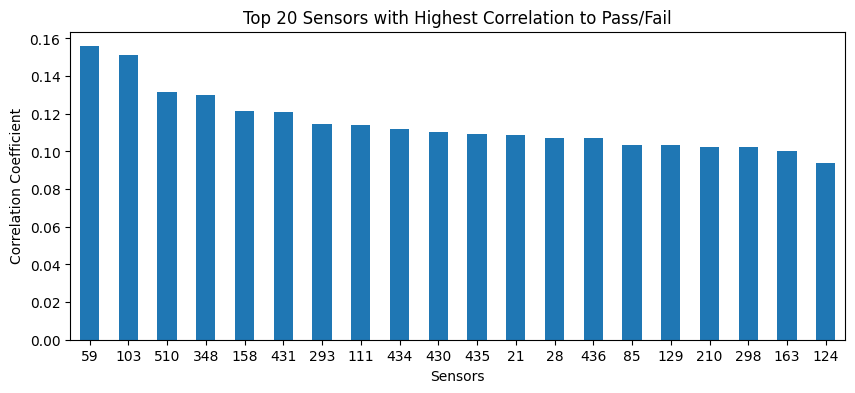

In [5]:
# 타겟 칼럼('Pass/Fail')과 다른 열과의 상관계수 확인
correlations = data.corr(numeric_only=True)['Pass/Fail'].sort_values(ascending=False)

# 상관계수 절댓값을 내림차순 정렬(상관계수 값이 음수일 수도 있기 때문), 상위 20개만 출력
top_20_sensors = correlations.abs().sort_values(ascending=False).head(21)

# 상위 20개의 센서를 막대 그래프로 나타내기
plt.figure(figsize=(10,4))
top_20_sensors[1:].plot(kind='bar')
plt.title('Top 20 Sensors with Highest Correlation to Pass/Fail')
plt.xlabel('Sensors')
plt.xticks(rotation=0)
plt.ylabel('Correlation Coefficient')
plt.show()


[해석]
- 보통 상관계수의 값이 0.1 ~ 0.2 이상이 되면 공정 결과에 큰 영향을 주는 것으로 파악함.
- 반도체 데이터는 변수가 워낙 많이 때문에, 상관계수 값이 0.1만 넘어도 유의미하게 보기도 함.
- 상관계수 크기가 0.1이 넘는 센서들은 유의미한 센서들임.

### 1-4-(C). 상관계수 상위 4개 센서 분석
- 상관계수 상위 4개 센서의 박스플롯, KDE 플롯 그래프를 해석

/tmp/ipykernel_442/2368626281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pass/Fail', y=sensor, data=data, ax=axes[i, 0], palette='Set1')
/tmp/ipykernel_442/2368626281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pass/Fail', y=sensor, data=data, ax=axes[i, 0], palette='Set1')
/tmp/ipykernel_442/2368626281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pass/Fail', y=sensor, data=data, ax=axes[i, 0], palette='Set1')
/tmp/ipykernel_442/2368626281.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is de

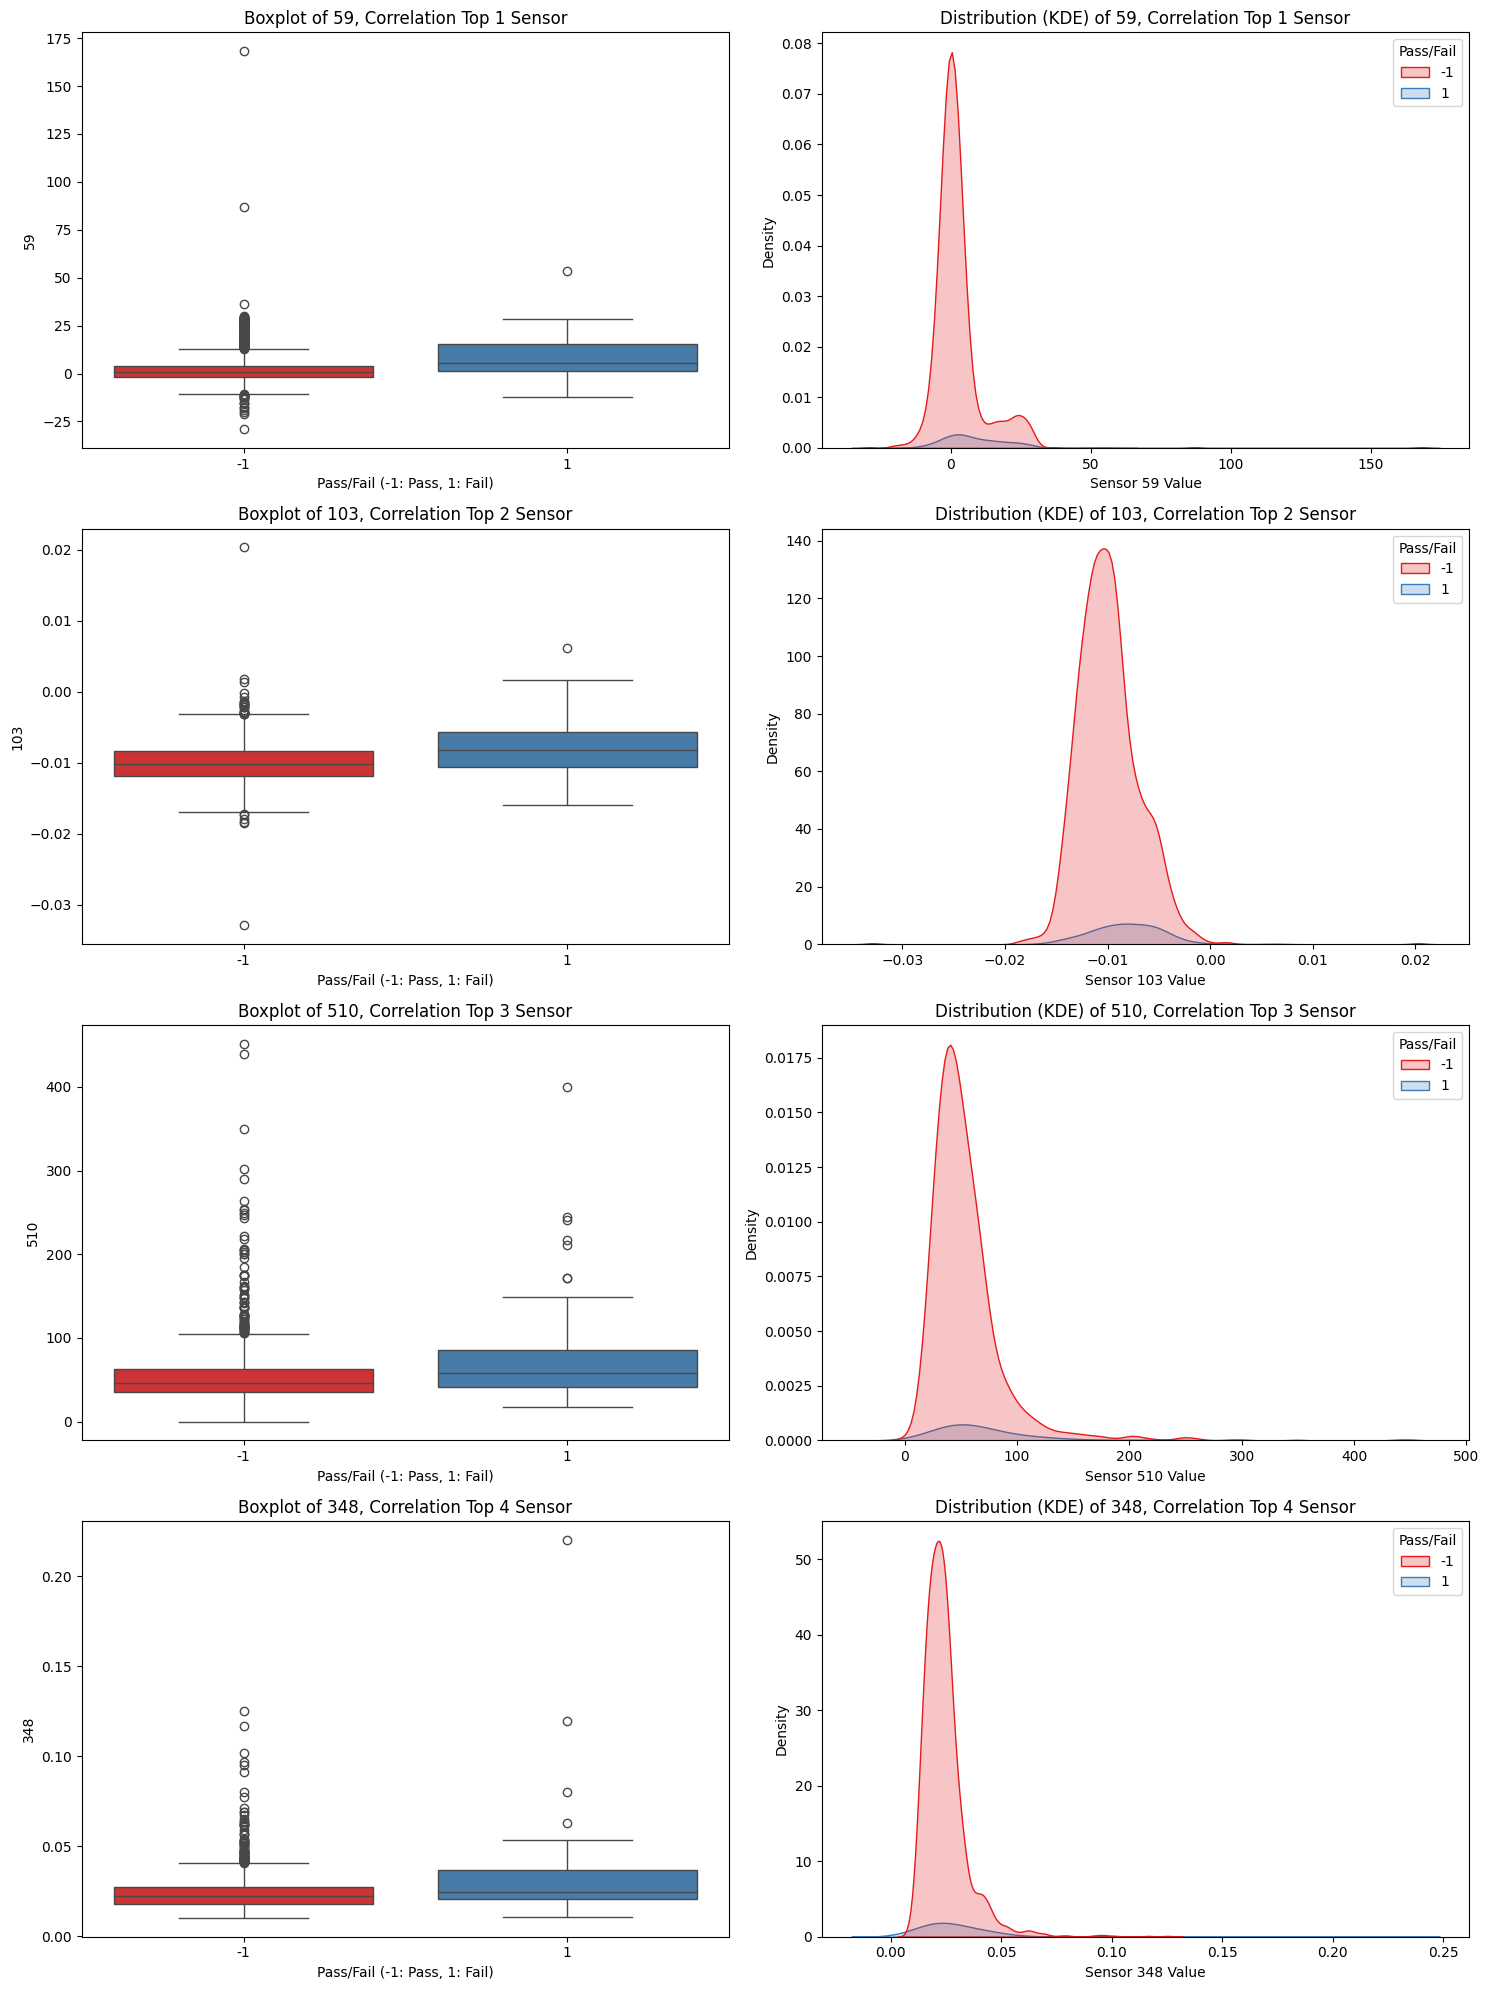

In [6]:
# 분석할 센서 4개 선정
target_sensors = ['59', '103', '510', '348']

# 그래프 영역 설정 (4행 2열)
fig, axes = plt.subplots(4, 2, figsize=(15, 20))

for i, sensor in enumerate(target_sensors):
    # 왼쪽: Box Plot
    sns.boxplot(x='Pass/Fail', y=sensor, data=data, ax=axes[i, 0], palette='Set1')
    axes[i, 0].set_title(f'Boxplot of {sensor}, Correlation Top {i+1} Sensor')
    axes[i, 0].set_xlabel('Pass/Fail (-1: Pass, 1: Fail)')

    # 오른쪽: KDE Plot
    sns.kdeplot(data=data, x=sensor, hue='Pass/Fail', fill=True, ax=axes[i, 1], palette='Set1')
    axes[i, 1].set_title(f'Distribution (KDE) of {sensor}, Correlation Top {i+1} Sensor')
    axes[i, 1].set_xlabel(f'Sensor {sensor} Value')

plt.tight_layout()
plt.show()

[해석]
- Fail일 때 센서들의 분포가 미세하지만 전반적으로 더 크게 형성되어있음.
- Pass 그룹에서 이상치들이 꽤 존재하는 것으로 보아, 추후 전처리 단계에서 이상치를 제거하지 않는 방법을 사용할 필요성이 느껴짐.

### 1-4-(D). 이상치 확인
- 그래프 분석 결과 데이터에 이상치가 상당히 존재한다는 것을 확인함.
- 이상치의 존재가 제품 성공/불량에 어느정도 영향을 미치는 지 확인할 필요성이 있음.

In [7]:
# 이상치 개수를 계산하는 함수 생성 (IQR 방식)
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

# 대상 센서 (상관계수 상위 4개)
target_sensors = ['59', '103', '510', '348']
results = []


for sensor in target_sensors:
    # 각 그룹별 데이터 추출
    pass_group = data[data['Pass/Fail'] == -1][sensor]
    fail_group = data[data['Pass/Fail'] == 1][sensor]

    # 그룹별 이상치 계산
    pass_outliers = count_outliers(pass_group)
    fail_outliers = count_outliers(fail_group)

    # 전체 대비 비율 계산
    pass_ratio = (pass_outliers / len(pass_group)) * 100
    fail_ratio = (fail_outliers / len(fail_group)) * 100

    # 결과 입력
    results.append({
        'Sensor': sensor,
        'Pass Outliers(count)': pass_outliers,
        'Pass Outliers Ratio(%)': round(pass_ratio, 2),
        'Fail Outliers(count)': fail_outliers,
        'Fail Outliers Ratio(%)': round(fail_ratio, 2)
    })

# 결과를 데이터프레임으로 출력
outlier_analysis = pd.DataFrame(results)
print(outlier_analysis)

  Sensor  Pass Outliers(count)  Pass Outliers Ratio(%)  Fail Outliers(count)  \
0     59                   175                   11.96                     1   
1    103                    31                    2.12                     1   
2    510                    78                    5.33                     7   
3    348                    86                    5.88                     4   

   Fail Outliers Ratio(%)  
0                    0.96  
1                    0.96  
2                    6.73  
3                    3.85  


[해석]
- 만약 이상치 비율이 Pass 그룹에서 낮다가 Fail 그룹에서 높아졌다면 이상치의 존재가 제품의 Fail에 큰 영향을 미친다는 뜻임.
- 그러나 이상치가 오히려 Pass 그룹에서 높게 관측되므로, 제품의 성공/실패 유무에 큰 영향을 끼치지 않는 것으로 판단됨.
- 따라서 이상치를 제거하는 것이 필요해보임.

# 2. 모델링 과정
- 2-1. 데이터 전처리
- 2-2. 모델 선택 및 평가

## 2-1. 데이터 전처리
- (A) 결측치 비율이 0.5 이상인 칼럼(센서) 제거
- (B) 상수 칼럼(분산=0) 제거
- (C) 이상치 처리
- (D) 결측치 처리
- (E) 데이터 스케일링
- (F) 다중공선성 해결
- (G) 변수 생성: 전반적 공정 변동성
- (H) 데이터 불균형 해소: SMOTE
- (I) 레이블 인코딩
- (J) 데이터 최종 타입 확인

### 2-1-(A). 결측치 비율이 0.5 이상인 칼럼(센서) 제거

In [8]:
# data 변수에 저장된 각 칼럼별 결측치 비율 계산
null_ratio = data.isnull().mean(axis=0)

# 결측치 비율이 0.5 이상인 칼럼들의 이름 추출
columns_to_drop = null_ratio[null_ratio >= 0.5].index.tolist()

# 기존 'data' 자료에서 해당 칼럼을 제거한 새로운 데이터를 'data_cleaned'에 저장
data_cleaned = data.drop(columns=columns_to_drop)

# 결과 확인
print(f"기존 칼럼 수: {data.shape[1]}개")
print(f"제거 대상 칼럼(결측치 50% 이상) 수: {len(columns_to_drop)}개")
print("-" * 40)
print(f"제거 후 남은 칼럼 수: {data_cleaned.shape[1]}개")

기존 칼럼 수: 592개
제거 대상 칼럼(결측치 50% 이상) 수: 28개
----------------------------------------
제거 후 남은 칼럼 수: 564개


### 2-1-(B). 상수 칼럼(분산=0) 제거
- 앞서 기초 통계량 확인을 통해 분산이 0인 센서들을 일부 발견하였음.
- 해당 센서는 값이 변하지 않으므로 상수와도 같기에 해당 칼럼들을 제거함.

In [9]:
# 각 칼럼별로 고유한 값(Unique Value)의 개수 확인
unique_counts = data_cleaned.nunique()

# Unique Value 가 1인 칼럼들의 이름 추출
single_value_columns = unique_counts[unique_counts == 1].index.tolist()

# 해당 칼럼들을 제거하여 새로운 변수인 'data_dropped'에 저장
data_dropped = data_cleaned.drop(columns=single_value_columns)

# 결과 확인
print(f"기존 칼럼 수: {data_cleaned.shape[1]}개")
print(f"제거 대상 칼럼(값이 변하지 않는 칼럼) 수: {len(single_value_columns)}개")
print("-" * 50)
print(f"제거 후 남은 칼럼 수: {data_dropped.shape[1]}개")

기존 칼럼 수: 564개
제거 대상 칼럼(값이 변하지 않는 칼럼) 수: 116개
--------------------------------------------------
제거 후 남은 칼럼 수: 448개


### 2-1-(C). 이상치 처리  
- EDA 과정에서 이상치가 Fail에 큰 영향을 주지 않는 것으로 확인함.
- 불량 데이터의 수가 매우 적으므로 이상치를 아예 삭제하는 것이 아닌, 특정 임계값으로 값을 깎아서 고정시키는 방법인 윈저라이징(Clipping) 방법을 이용.
- 임계값은 1%를 사용함.

In [10]:
# 'Time'과 'Pass/Fail' 컬럼은 제외하고 센서 데이터만 선택
sensors = data_dropped.drop(columns=['Time', 'Pass/Fail']).columns

# 각 센서별로 상위 1%와 하위 1%에서 Clipping 수행
for col in sensors:
    lower_limit = data_dropped[col].quantile(0.01)
    upper_limit = data_dropped[col].quantile(0.99)

    data_dropped[col] = data_dropped[col].clip(lower=lower_limit, upper=upper_limit)

# data_final 에 저장
data_final = data_dropped.copy()

# 결과 출력
print(f"윈저라이징 완료, 데이터 형태: {data_final.shape}")

윈저라이징 완료, 데이터 형태: (1567, 448)


이상치 상위 4개 센서의 이상치를 분석하는 코드를 다시 실행하여, 이상치 처리 전후 비교

In [11]:
# 이상치 개수를 계산하는 함수 생성 (IQR 방식)
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((series < lower_bound) | (series > upper_bound)).sum()

# 대상 센서 (상관계수 상위 4개)
target_sensors = ['59', '103', '510', '348']
results = []


for sensor in target_sensors:
    # 각 그룹별 데이터 추출
    pass_group = data_final[data_final['Pass/Fail'] == -1][sensor]
    fail_group = data_final[data_final['Pass/Fail'] == 1][sensor]

    # 그룹별 이상치 계산
    pass_outliers = count_outliers(pass_group)
    fail_outliers = count_outliers(fail_group)

    # 전체 대비 비율 계산
    pass_ratio = (pass_outliers / len(pass_group)) * 100
    fail_ratio = (fail_outliers / len(fail_group)) * 100

    # 결과 입력
    results.append({
        'Sensor': sensor,
        'Pass Outliers (count)': pass_outliers,
        'Pass Outliers Ratio (%)': round(pass_ratio, 2),
        'Fail Outliers (count)': fail_outliers,
        'Fail Outliers Ratio (%)': round(fail_ratio, 2)
    })

# 결과 출력
outlier_analysis = pd.DataFrame(results)
print("[이상치 처리 후]\n")
print(outlier_analysis)

[이상치 처리 후]

  Sensor  Pass Outliers (count)  Pass Outliers Ratio (%)  \
0     59                    175                    11.96   
1    103                     25                     1.71   
2    510                     78                     5.33   
3    348                     86                     5.88   

   Fail Outliers (count)  Fail Outliers Ratio (%)  
0                      0                     0.00  
1                      0                     0.00  
2                      7                     6.73  
3                      4                     3.85  


[이상치 처리 전]

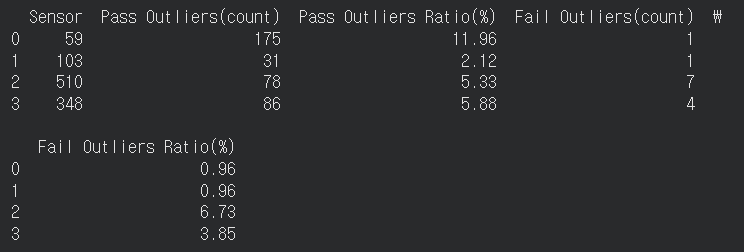

[이상치 처리 결과]
- Sensor 59: Fail Outlier 1개 감소
- Sensor 103: Pass Outlier 6개 감소, Fail Outlier 1개 감소

### 2-1-(D). 결측치 처리  
- 이상치가 많으므로 결측치를 평균값이 아닌 중앙값으로 채움.

In [12]:
# 현재 결측치 개수 확인
print(f"[결측치 채우기 전] 총 결측치 개수: {data_final.isnull().sum(axis=0).sum()}\n")

# 각 칼럼의 중앙값(median) 계산
# 날짜 데이터는 오류가 발생하므로, 숫자 데이터만 계산하기
columns_medians = data_final.median(numeric_only=True)

# 계산한 중앙값으로 결측치 채우기 -> data_final_imputed 에 저장
data_final_imputed = data_final.fillna(columns_medians)

# 결과 확인
print("---------결측치를 중앙값으로 채우기 수행---------\n")
print(f"[결측치 채운 후] 총 결측치 개수: {data_final_imputed.isnull().sum(axis=0).sum()}")

[결측치 채우기 전] 총 결측치 개수: 10868

---------결측치를 중앙값으로 채우기 수행---------

[결측치 채운 후] 총 결측치 개수: 0


### 2-1-(E). 데이터 스케일링
- 센서마다 값의 사이즈가 다르므로 스케일링을 진행해야 함.
- 현재 데이터는 이상치가 많으므로 그에 적합한 RobustScaler를 사용.

In [13]:
# RobustScaler 불러오기
from sklearn.preprocessing import RobustScaler

# 객체 할당
rb_scaler = RobustScaler()

# 특성(x)과 타겟(y) 분리하기
# 'Pass/Fail'은 우리가 맞춰야 할 타겟(y)으로 분류한다.
# 'Time' 열은 숫자 데이터가 아니라 날짜이므로 제외한다.
x = data_final_imputed.drop(columns=['Pass/Fail', 'Time'])
y = data_final_imputed['Pass/Fail']

# 데이터 학습 및 변환
x_scaled = rb_scaler.fit_transform(x)

# 결과를 데이터프레임으로 변환 -> x_scaled_df 에 저장
x_scaled_df = pd.DataFrame(x_scaled)

# 결과 출력
print("[데이터 스케일링 수행]")
print("5개 샘플 출력")
x_scaled_df.head()

[데이터 스케일링 수행]
5개 샘플 출력


,0,1,2,3,4,5,6,7,8,9,...,436,437,438,439,440,441,442,443,444,445
0,0.216300,0.752329,-0.360796,0.248699,0.086609,-0.591441,0.666667,0.368371,0.911458,-0.330435,...,0.105359,0.203070,0.067416,-0.408163,-0.100,-0.399261,0.000000,0.000000,0.000000,0.000000
1,0.937858,-0.399080,0.794346,0.352463,-0.972660,0.126073,0.851852,0.331439,0.041667,-1.321739,...,-1.049539,-0.522928,0.382022,1.734694,1.900,1.706763,-0.770318,0.546392,0.451613,1.936656
2,-0.877663,0.705043,-0.396574,0.815358,0.385951,-0.913868,0.629630,-0.170455,0.281250,0.078261,...,0.953703,-0.814754,-0.988764,0.387755,0.300,0.421721,2.420141,3.363402,3.290323,0.155719
3,-0.253352,-0.227172,-0.055023,-0.741524,0.007184,0.413291,-0.259259,0.251894,-0.578125,-0.321739,...,0.271502,-0.938245,-0.269663,-0.714286,-1.100,-0.711467,-0.021201,0.010309,-0.064516,0.027603
4,0.230876,0.040356,0.874023,0.081586,0.432249,-0.169215,0.407407,0.392992,-0.093750,-0.660870,...,0.071320,-0.510472,-1.738202,5.212245,4.435,5.113880,-0.021201,0.010309,-0.064516,0.027603


### 2-1-(F).다중공선성(Multicollinearity) 해결  
- 반도체 공정 특성상 여러 센서가 동일한 압력이나 온도를 측정하여 데이터가 서로 강한 상관관계를 가지는 경우가 발생함.
- 중복된 정보는 모델을 복잡하게 만들고 해석을 어렵게 하므로, 서로 상관계수가 0.9 이상인 센서들 중 하나만 남기고 삭제하여 다중공선성을 해결.

In [14]:
# 센서 간 상관계수 행렬 계산(절댓값)
# 현재 남아있는 센서는 446개이기 때문에, 행렬의 크기는 446 x 446 임.
corr_matrix = x_scaled_df.corr().abs()

# 중복 계산을 방지하기 위해 상삼각 행렬(Upper triangle)만 선택
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 상관계수가 0.9 넘는 칼럼 찾기
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# 해당 칼럼들 제거하기 -> x_final 에 저장
x_final = x_scaled_df.drop(columns=to_drop)

print("[상관계수가 0.9 이상인 칼럼 제거]")
print(f"기존 칼럼 수: {x_scaled_df.shape[1]}개")
print(f"상관계수가 0.9 이상인 칼럼 수: {len(to_drop)}개")
print("-" * 40)
print(f"남은 칼럼 수: {len(x_final.columns)}개")

[상관계수가 0.9 이상인 칼럼 제거]
기존 칼럼 수: 446개
상관계수가 0.9 이상인 칼럼 수: 195개
----------------------------------------
남은 칼럼 수: 251개


### 2-1-(G). 변수 생성: 전반적 공정 변동성
- 현재 데이터의 칼럼명은 마스크 처리되어있어 그 실체를 알 수 없음.
- 이러한 상황에서 특정 변수를 조합해 새로운 의미있는 변수를 만들어 내는 것은 힘들다고 생각됨.
- 그러나 각 행(샘플)별 통계량을 구하는 것은 해당 제품이 생산될 때 공정 전체가 얼마나 안정적이었는지를 보여주는 의미있는 지표가 될 가능성이 있다고 생각함.
- 각 행(샘플)별로 주요 센서들의 값이 평균에서 얼마나 벗어나 있는지 그 변동의 합을 구하는 개념으로, "이 샘플의 공정에서는 전반적으로 센서들이 요동치고 있는가?" 를 수치화한 지표로 생성.
- 이를 위해 각 샘플별 센서와의 평균값(mean)과 표준편차(std) 변수를 생성.

In [15]:
# 변수 생성 전 데이터 크기
print(f"변수 생성 전 데이터 크기: {x_final.shape}\n")

# 요약 변수를 생성할 센서 리스트 (Pass/Fail, Time 등 타겟 제외)
sensor_columns = [col for col in x_final.columns if col not in ['Time', 'Pass/Fail']]

# 전체 센서에 대한 행별 평균값 통계량 'row_mean' 변수 생성 -> 칼럼 1000에 저장
x_final[1000] = x_final[sensor_columns].mean(axis=1)

# 전체 센서에 대한 행별 표준편차 통계량 'row_std' 변수 생성 -> 칼럼 1001에 저장
x_final[1001] = x_final[sensor_columns].std(axis=1)

print("새로운 변수 'row_mean', 'row_std' 생성 완료.\n")
print(x_final[[1000, 1001]])
print(f"현재 데이터 크기: {x_final.shape, y.shape}")

변수 생성 전 데이터 크기: (1567, 251)

새로운 변수 'row_mean', 'row_std' 생성 완료.

          1000      1001
0     0.082863  1.154000
1     0.068626  0.897337
2     0.217087  2.322168
3     0.048388  1.001499
4     0.165624  0.977972
...        ...       ...
1562  0.069329  0.908646
1563  0.072174  1.000702
1564  0.017928  0.635251
1565  0.062170  0.796580
1566  0.065870  0.792704

[1567 rows x 2 columns]
현재 데이터 크기: ((1567, 253), (1567,))


### 2-1-(H). 데이터 불균형 해소: SMOTE
- 현재 데이터는 '성공'이 압도적으로 많음. 이 상태로 모델을 학습하면 모델이 무조건 '성공'이라고 예측하는 편향이 발생할 수 있음.
- SMOTE(Synthetic Minority Over-sampling Technique) 기법은 부족한 '실패' 데이터를 수학적으로 생성하여 성공 데이터와 실패 데이터의 비율을 맞춰주는 기법임.
- 현재 정상 데이터는 1463 개, 불량 데이터는 104 개임. 전체 데이터 대비 불량의 비율은 약 6%
- 정상 대비 불량의 비율을 30%로 우선 늘려 모델을 학습하고, 성능을 더 높일 필요성이 생기면 100%까지 늘려보기로 함.

In [16]:
# SMOTE import
from imblearn.over_sampling import SMOTE

# SMOTE 객체 생성, 랜덤 시드 42
# 초기 접근: 불량(1) 데이터를 정상(-1) 데이터의 30% 수준까지 생성해본다.
# 추후 sampling_strategy의 비율을 1까지 올려 성공과 실패의 비율을 1:1로 맞출 예정이다.
smote = SMOTE(sampling_strategy=0.3, random_state=42)

# 실패 데이터 생성
x_resampled, y_resampled = smote.fit_resample(x_final, y)

print(f"[SMOTE 전]\n실패 데이터: {len(y[y == 1])}개\n성공 데이터: {len(y[y == -1])}개\n전체 데이터 중 실패 데이터 비율: {np.round(len(y[y == 1]) / len(y) * 100, 2)}%\n")
print(f"[SMOTE 후]\n실패 데이터: {len(y_resampled[y_resampled == 1])}개\n성공 데이터: {len(y_resampled[y_resampled == -1])}개\n전체 데이터 중 실패 데이터 비율: {np.round(len(y_resampled[y_resampled == 1]) / len(y_resampled) * 100, 2)}%")

[SMOTE 전]
실패 데이터: 104개
성공 데이터: 1463개
전체 데이터 중 실패 데이터 비율: 6.64%

[SMOTE 후]
실패 데이터: 438개
성공 데이터: 1463개
전체 데이터 중 실패 데이터 비율: 23.04%


### 2-1-(I). 레이블 인코딩
- 현재 타겟(y_resampled) 값은 정상(-1), 불량(1)로 되어있음.
- 최신 머신러닝 알고리즘(XGBoost 등) 은 정답 레이블이 0부터 시작하는 양수여야만 동작하는 경우가 있기에, 정상을 -1에서 0으로 변경함.

In [17]:
# Pass(-1)을 Pass(0)으로 변경
y_final = y_resampled.replace({-1: 0})
print(f"레이블 변경 확인: {y_final.value_counts()}")

레이블 변경 확인: Pass/Fail
0    1463
1     438
Name: count, dtype: int64


### 2-1-(J). 데이터 최종 타입 확인  
- 'Date'와 같은 칼럼은 숫자가 아닌 문자열(Object) 칼럼이기때문에 모델이 계산을 못하고 에러를 발생시킴.
- 데이터가 최종적으로 숫자만 있는지 확인함.

In [18]:
# 숫자가 아닌 칼럼이 남아있는지 확인
non_numeric_final = x_resampled.select_dtypes(exclude=[np.number]).columns
print(f"남아있는 비숫자 칼럼: {non_numeric_final}")

남아있는 비숫자 칼럼: Index([], dtype='int64')


## 2-2. 모델 선택 및 평가
- (A) 모델 성능 지표 시각화 함수 정의
- (B) RandomForest, LightGBM, XGBoost 학습 및 최적의 모델 선정
- (C) 모델 개선: 하이퍼파라미터 튜닝 + CV

### 2-2-(A). 모델 성능 지표 시각화 함수 정의
- 모델의 성능 개선에 앞서, 모델의 성능 평가 지표 시각화를 위한 함수 'score' 정의
- Classification Report, Cunfusion Matrix, ROC Curve를 한 번에 보여주는 함수임.

In [22]:
# Classification Report, Confusion Matrix 및 ROC Curve 시각화 함수 'score' 정의
# 점수를 평가할 model, test_input, test_target, model_pred(모델이 예측한 결과) 을 인수로 받음


def score(model, test_input, test_target, model_pred):
  from sklearn.metrics import roc_auc_score, RocCurveDisplay
  from sklearn.metrics import classification_report, confusion_matrix

  # 1 x 3 공간 생성
  fig, ax = plt.subplots(1, 3, figsize=(12, 4))

  # 1. confusion matrix 생성
  cm = confusion_matrix(test_target, model_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Pass(0)', 'Fail(1)'],
              yticklabels=['Pass(0)', 'Fail(1)'],
              ax = ax[0])
  ax[0].set_title('Confusion Matrix')
  ax[0].set_xlabel('Predicted')
  ax[0].set_ylabel('Actual')

  # 2. Classification Report를 딕셔너리 형태로 생성 후 데이터프레임으로 변환 -> 히트맵 작성
  report = classification_report(test_target, model_pred, output_dict=True)
  df_report = pd.DataFrame(report).iloc[:-1, :2].T
  sns.heatmap(df_report,
              annot=True,
              cmap='RdYlGn',
              fmt='.2f',
              cbar=False,
              yticklabels=['0(Pass)', '1(Fail)'],
              ax=ax[1])
  ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=0)
  ax[1].set_title('Classification Report Heatmap')

  # 3. ROC Curve 생성
  RocCurveDisplay.from_estimator(model, test_input, test_target, ax = ax[2])
  ax[2].set_title('ROC Curve')
  ax[2].grid(True)

  plt.tight_layout()
  plt.show()

### 2-2-(B). RandomForest, LightGBM, XGBoost 학습 및 최적의 모델 선정
3개의 모델을 기본 파라미터로 테스트한 뒤, 가장 우수한 모델을 튜닝한다.

In [23]:
# 데이터를 입력(input), 출력(target)으로 분리
input = x_resampled
target = y_final

# train_test_split을 이용해 학습용 80%, 검증용 20%로 데이터를 나눈다. 이때 제품의 불량률이 23%로 미미함.
# 따라서 해당 비율을 골고루 나누기 위해 startify=target 을 통해 불량률 비율을 적절히 분배.
from sklearn.model_selection import train_test_split

# 데이터 분할(학습용 80%, 검증용 20%)
train_input, test_input, train_target, test_target = train_test_split(input, target, test_size=0.2, random_state=42, stratify=target)

RandomForest 학습 소요 시간: 2.24초

[RandomForest 모델 성능]


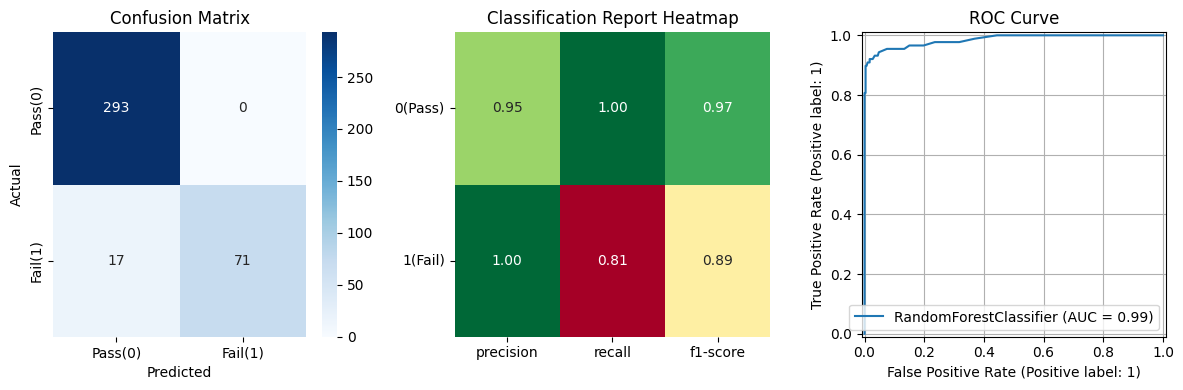



[LightGBM] [Info] Number of positive: 350, number of negative: 1170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 60639
[LightGBM] [Info] Number of data points in the train set: 1520, number of used features: 247
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230263 -> initscore=-1.206826
[LightGBM] [Info] Start training from score -1.206826
LightGBM 학습 소요 시간: 2.86초

[LightGBM 모델 성능]


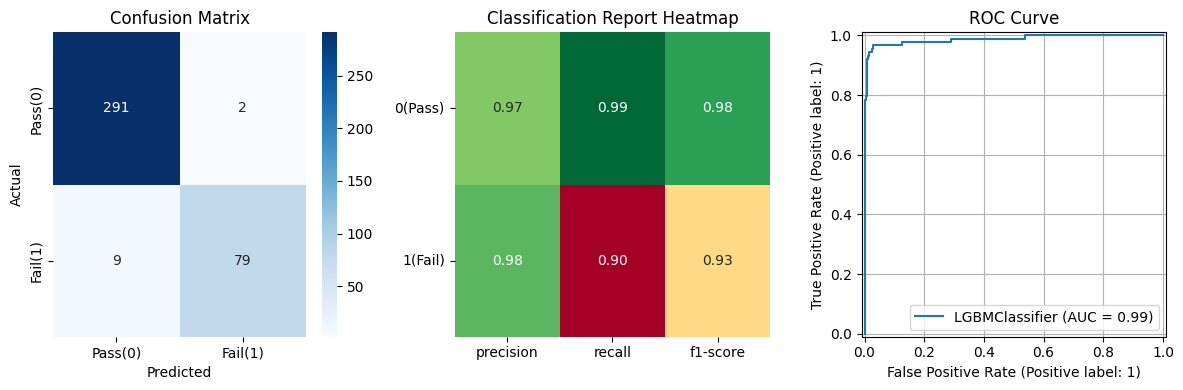



XGBoost 학습 소요 시간: 2.31초

[XGBoost 모델 성능]


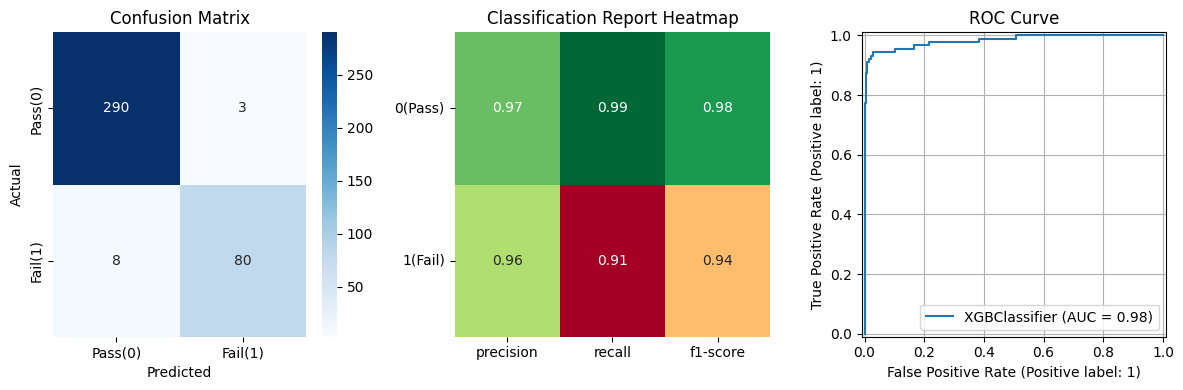

In [24]:
# 모델 훈련 시간을 기록하기 위해 time 라이브러리 불러오기
import time

# RandomForest 모델 생성
# 실패 23%인 불균형 데이터이므로. class_weight='balanced'로 두어 학습 시 가중치를 조절한다.
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# LightGBM 모델 생성
# 불량률이 23%인 불균형 데이터이므로 scale_pos_weight를 100/23 = 3.34 로 조정해야 함.
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=42, n_jobs=-1, scale_pos_weight=3.34)

# XGBoost 모델 생성
# 불량률이 23%인 불균형 데이터이므로 scale_pos_weight를 100/23 = 3.34 로 조정해야 함.
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=3.34)




# RandomForest 훈련 시간 및 성능 출력
start_time = time.time()
rf.fit(train_input, train_target)
end_time = time.time()
fit_time = end_time - start_time
print(f"RandomForest 학습 소요 시간: {round(fit_time, 2)}초\n")

rf_pred = rf.predict(test_input) # test_input에 대한 RandomForest의 예측 데이터
print("[RandomForest 모델 성능]")
score(rf, test_input, test_target, rf_pred)
print("\n")




# LightGBM 훈련 시간 및 성능 출력
start_time = time.time()
lgbm.fit(train_input, train_target)
end_time = time.time()
fit_time = end_time - start_time
print(f"LightGBM 학습 소요 시간: {round(fit_time, 2)}초\n")

lgbm_pred = lgbm.predict(test_input) # test_input에 대한 RandomForest의 예측 데이터
print("[LightGBM 모델 성능]")
score(lgbm, test_input, test_target, lgbm_pred)
print("\n")




# XGBoost 훈련 시간 및 성능 출력
start_time = time.time()
xgb.fit(train_input, train_target)
end_time = time.time()
fit_time = end_time - start_time
print(f"XGBoost 학습 소요 시간: {round(fit_time, 2)}초\n")

xgb_pred = xgb.predict(test_input) # test_input에 대한 RandomForest의 예측 데이터
print("[XGBoost 모델 성능]")
score(xgb, test_input, test_target, xgb_pred)
print("\n")

[최적의 모델 선정]
- XGBoost 모델이 Fail에서 recall, f1-score이 가장 높으므로 해당 모델을 튜닝하여 성능을 더욱 높여봄.

### 2-2-(C). 모델 개선: XGBoost GridSearchCV

Fitting 2 folds for each of 8 candidates, totalling 16 fits
튜닝 완료, 소요 시간: 70.91초


[최적 파라미터]
{'learning_rate': 0.3, 'max_depth': 9, 'n_estimators': 200}


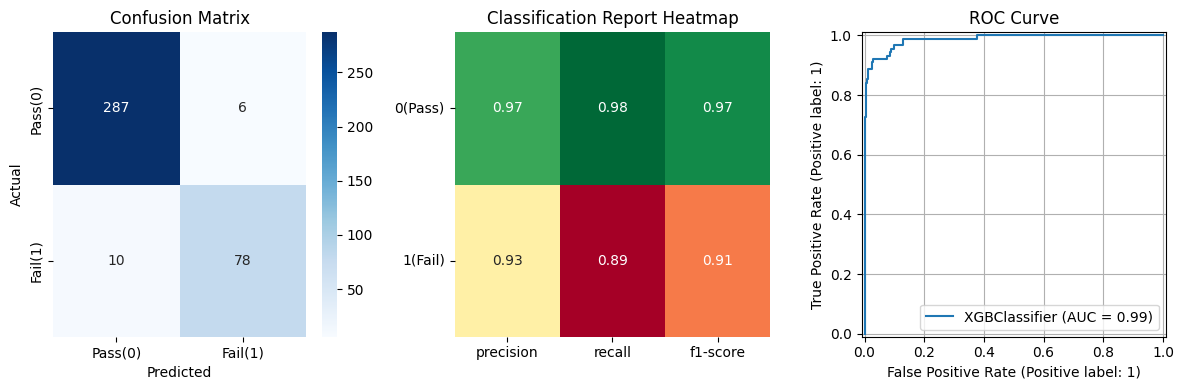

In [25]:
from sklearn.model_selection import GridSearchCV

# 탐색할 하이퍼파라미터 범위
param_grid = {
    'learning_rate': [0.1, 0.3],       # 학습 강도 (기본값 0.3, 낮을수록 정교, 클수록 빠름)
    'max_depth': [6, 9],               # 나무 깊이 (기본값 6, 데이터가 복잡하면 정밀한 패턴 파악을 위해 늘리는게 좋음)
    'n_estimators': [100, 200]         # 나무 개수 (기본값 100)
}

# GridSearchCV 객체 생성
grid_xgb = GridSearchCV(
                  estimator=xgb,
                  param_grid=param_grid,
                  cv=2,
                  n_jobs=-1,
                  verbose=1,
                  scoring='f1')

# 훈련 및 튜닝 시간 기록
start_time = time.time()
grid_xgb.fit(train_input, train_target)
end_time = time.time()
fit_time = end_time - start_time
print(f"튜닝 완료, 소요 시간: {round(fit_time, 2)}초\n")

# 최적 파라미터 출력
print(f"\n[최적 파라미터]\n{grid_xgb.best_params_}")

# 예측 데이터 생성
best_xgb = grid_xgb.best_estimator_
xgb_pred = best_xgb.predict(test_input)

# 모델의 성능 확인
score(best_xgb, test_input, test_target, xgb_pred)

[튜닝 결과 분석]
- max_depth: 6 -> 9로 증가
- n_estimateors: 100 -> 200로 증가
- recall: 0.91 -> 0.89로 감소
- f1-score: 0.94 -> 0.91로 감소
- 튜닝 결과 Fail의 recall, f1-score가 전반적으로 감소한 것이 확인됨. 하이퍼파라미터 튜닝이 실제 target 예측에는 오히려 안좋은 영향을 끼침.
- 따라서 기본 파라미터가 최적의 모델로 선정

# 3. 프로젝트를 통해 얻은 인사이트
- 3-1. 핵심 센서 추출
- 3-2. 기타 인사이트

## 3-1. 핵심 센서 추출
- EDA 과정에서 도출한 상관계수 상위 센서와 RandomForest, LightGBM, XGBoost 특성 중요도 상위 센서를 관찰함.

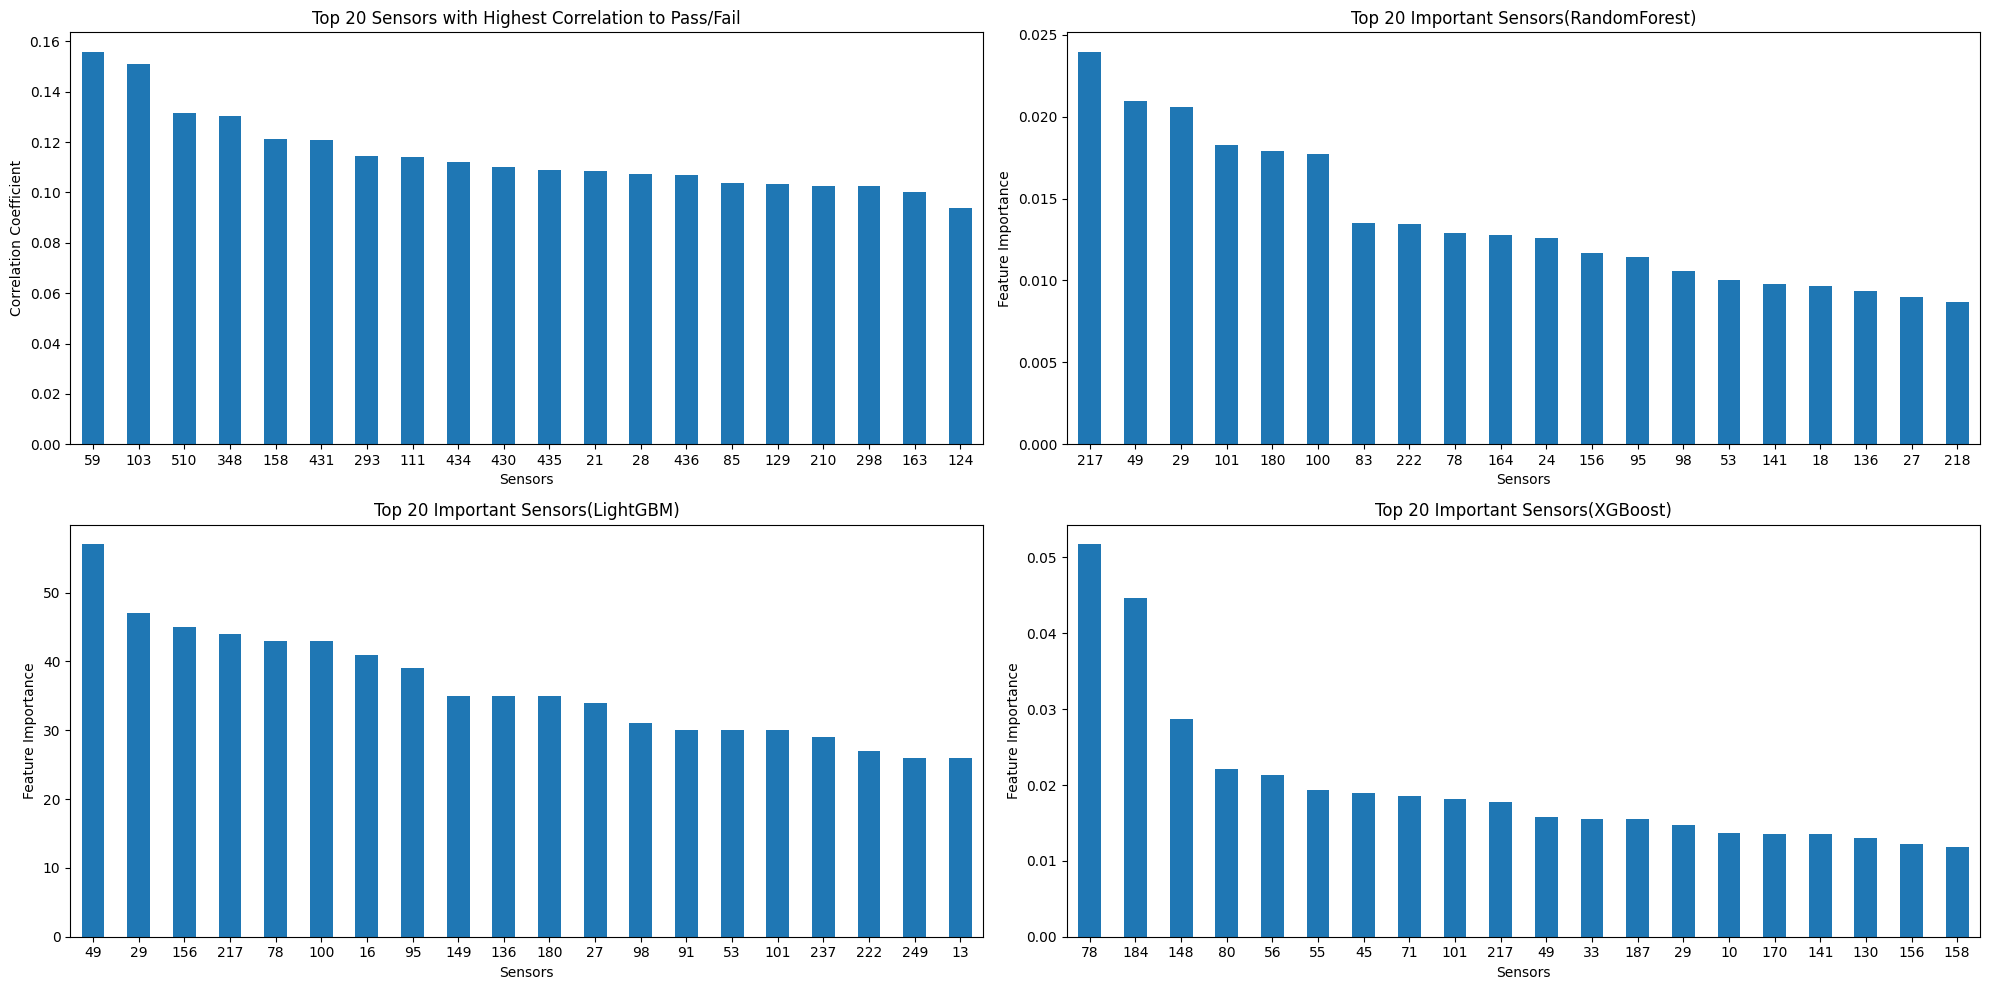

In [26]:
# 4행 1열에 상관계수, RandomForest, LightGBM, XGBoost에서 중요한 센서들을 시각화함
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

# 1행: 상관계수 상위 20 센서
top_20_sensors[1:].plot(kind='bar', ax=ax[0, 0])
ax[0, 0].set_title('Top 20 Sensors with Highest Correlation to Pass/Fail')
ax[0, 0].set_xlabel('Sensors')
ax[0, 0].set_xticklabels(ax[0, 0].get_xticklabels(), rotation=0)
ax[0, 0].set_ylabel('Correlation Coefficient')

# 2행: RandomForest 특성 중요도 상위 20개 센서 시각화
feature_importances_rf = pd.Series(rf.feature_importances_).sort_values(ascending=False)
feature_importances_rf[:20].plot(kind='bar', ax=ax[0, 1])
ax[0, 1].set_title("Top 20 Important Sensors(RandomForest)")
ax[0, 1].set_xlabel("Sensors")
ax[0, 1].set_xticklabels(ax[0, 1].get_xticklabels(), rotation=0)
ax[0, 1].set_ylabel("Feature Importance")

# 3행: LightGBM 특성 중요도 상위 20개 센서 시각화
feature_importances_lgbm = pd.Series(lgbm.feature_importances_).sort_values(ascending=False)
feature_importances_lgbm[:20].plot(kind='bar', ax=ax[1, 0])
ax[1, 0].set_title("Top 20 Important Sensors(LightGBM)")
ax[1, 0].set_xlabel("Sensors")
ax[1, 0].set_xticklabels(ax[1, 0].get_xticklabels(), rotation=0)
ax[1, 0].set_ylabel("Feature Importance")

# 4행: XGBoost 특성 중요도 상위 20개 센서 시각화
feature_importances_xgb = pd.Series(xgb.feature_importances_).sort_values(ascending=False)
feature_importances_xgb[:20].plot(kind='bar', ax=ax[1, 1])
ax[1, 1].set_title("Top 20 Important Sensors(XGBoost)")
ax[1, 1].set_xlabel("Sensors")
ax[1, 1].set_xticklabels(ax[1, 1].get_xticklabels(), rotation=0)
ax[1, 1].set_ylabel("Feature Importance")

plt.tight_layout()
plt.show()

[결과 분석]
- 의미있는 센서를 도출하기 위한 인사이트를 3개로 나누었다.
- 1: 모든 모델에서 공통적으로 상위권에 위치한 센서
- 2: 선형(상관계수) vs 비선형(머신러닝) 관계의 분리
- 3: 미세 불량을 잡아내는 트리거 인자

1. 모든 모델에서 공통적으로 상위권에 위치한 센서
- 해당 센서: 49, 29, 217
- 선정 이유: 이 센서들은 RandomForest, LightGBM, XGBoost라는 서로 다른 알고리즘에서 모두 최상위권에 올라와 있음. 모델의 구동 방식이 다름에도 공통적으로 중요하다고 판단했다는 것은, 이 변수들이 불량 유무를 결정짓는 가장 지배적인 원인이라는 뜻임.
- 분석 포인트: 모든 ML 모델에서 큰 비중을 차지하므로, 공정 전체의 수율을 결정하는 '메인 파라미터'일 가능성이 매우 높음.

2. 선형(상관계수) vs 비선형(머신러닝) 관계의 분리
- 해당 센서: 59, 103 (상관계수 높음) vs 49, 29 (상관계수 낮음, ML 중요도 높음)
- 선정 이유: 59번, 103번은 각각 상관계수 1, 2위 센서. 그러나 ML 모델에서는 큰 힘을 쓰지 못함. 반대로 ML에서 중요한 49번, 29번은 상관계수 순위권에 없음.
- [분석 포인트]
- 59번, 103번: 값의 증감에 따라 불량률이 일정하게 변하는 '단순 지표'임. 관리는 쉽지만, 이것만 조절한다고 불량이 완전히 해결되지는 않음.
- 49, 29번: 특정 조건이 갖춰졌을 때만 불량을 일으키는 '복합 원인'일 확률이 큼. 단순히 값이 높고 낮음의 문제가 아니라, 다른 센서와의 조합이 중요할 것으로 보임.

3. 미세 불량을 잡아내는 트리거 인자
- 해당 센서: 78, 184 (XGBoost 특화)
- 선정 이유: 78번과 184번은 유독 XGBoost 그래프에서만 1, 2위를 차지하며 툭 튀어나와 있음.
- 분석 포인트:  XGBoost는 이전 모델이 틀린 오차를 집중적으로 학습하는 특성이 있음. 현재 데이터는 불량 비율이 23%나 되는데, 일반적인 모델이 놓치기 쉬운 까다로운 불량 케이스들을 이 센서들이 설명해주고 있을 가능성이 큼. 전체적인 흐름보다는 특이 케이스를 잡아낼 때 핵심적인 역할을 하는 센서들임.

핵심 센서 및 분석 결과를 종합해보면 다음과 같다.


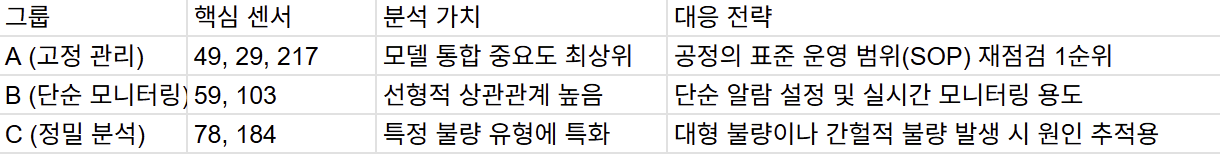

## 3-2. 기타 인사이트
- 앞서 Feature Engineering에서 샘플별 센서와의 평균값(mean)과 표준편차(std) 변수를 각각 1000, 1001 칼럼으로 새롭게 생성하였음.
- ML 학습 결과 해당 칼럼들은 특성 중요도 상위권에 존재하지 못했음. 즉, 의미있는 센서가 되지 못했음을 의미함.

# 4. 향후 개선 방향

모델 평가: 기본 파라미터를 적용한 XGBoost가 불량(1) 제품을 잡아내는 데에 f1-score(0.94), recall(0.91) 부문에서 가장 우수한 성능을 보였음. 실제 현장에서는 0.9가 넘는 모델이라면 사용하기 문제가 없는 정도라고 함. 높은 수준의 모델을 만들었다고 생각함. 하이퍼파라미터 튜닝을 그리드서치로 진행하였으나, 실행한 경우의 수가 16가지임. 조금 더 많은 변수들을 탐색하면 더 좋은 모델이 만들어지지 않았을까라는 생각이 듦. 파라미터 범위를 늘려서 더 많은 경우의 수를 탐색하여 모델의 성능을 평가해보는 활동이 필요해보임.

주요 센서 분석 평가: 칼럼의 수가 많다보니 소수의 특정 센서만 중요하다라고 분석하기 어려웠음. 앞서 분석했던 것처럼 단순 선형적인 상관관계가 높은 센서와 ML에서 중요한 센서들이 복합적으로 얽혀있음. 또한 특성 중요도가 다른 센서에 비해 클지라도, 그 값의 차이가 미세한 경우가 많았음. 이러한 경우 어느 정도 범위까지 중요한 센서라고 판단해야 하는지 그 기준을 명확히 잡기가 어려웠음. 향후 개선 사항으로 해당 기준을 보다 정밀하게 수립하는 것이 필요해보임.

# 5. Pilot Project 후기

칼럼의 수가 많은 데이터를 선정하였기에 결과적으로 분석 결과가 데이터의 흐름을 뚜렷하게 보여주지는 못했던 것 같음. 그러나, Develop Session을 진행하면서 배웠던 기법들과 기본적인 데이터 전처리 기법들을 다양하게 적용해볼 수 있는 기회라고 생각함. 처음 데이터 분석이라는 활동을 해보았는데, 이미 존재하는 라이브러리의 성능이 생각보다 너무 뛰어나 데이터 분석가가 해당 기법들의 자세한 원리를 알지 못하더라도 코드만 짤 줄 안다면 누구나 데이터 분석을 할 수 있겠다라는 생각이 들었음.

가장 아쉬웠던 점은 아직 Python 문법에 익숙하지 않아 특정 상황에서 어떤 코드를 작성해야 할 지가 잘 떠오르지 않는다는 점임. 다양한 종류의 데이터들을 분석해보는 활동을 꾸준히 하면서 코딩에 익숙해질 필요가 있음.